<a href="https://colab.research.google.com/github/Tijo622/Cybersecurity/blob/main/Cybersecurity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0))

CUDA Available: True
Device Name: Tesla T4


In [ ]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib


In [ ]:
train_zip = '/content/GUIDE_Train.csv.zip'
with zipfile.ZipFile(train_zip, 'r') as zip_ref:
   zip_ref.extractall()

In [ ]:
def optimize_memory(df):
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')
    return df

In [ ]:
chunks = []
train_data = "/content/GUIDE_Train.csv"
# Reading the dataset in chunks and process each chunk
for chunk in pd.read_csv(train_data, chunksize=500000,low_memory=False):
    chunk = optimize_memory(chunk)
    chunks.append(chunk)

# Concatenate all chunks into a single DataFrame
train_dataset = pd.concat(chunks, ignore_index=True)

# Clean up memory
del chunks

In [ ]:
train_dataset

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,180388628218,0,612,123247,2024-06-04T06:05:15.000Z,7,6,InitialAccess,NaN,TruePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,31,6,3
1,455266534868,88,326,210035,2024-06-14T03:01:25.000Z,58,43,Exfiltration,NaN,FalsePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
2,1056561957389,809,58352,712507,2024-06-13T04:52:55.000Z,423,298,InitialAccess,T1189,FalsePositive,...,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
3,1279900258736,92,32992,774301,2024-06-10T16:39:36.000Z,2,2,CommandAndControl,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
4,214748368522,148,4359,188041,2024-06-15T01:08:07.000Z,9,74,Execution,NaN,TruePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9516832,1056561956622,0,90,496631,2024-06-08T15:26:08.000Z,7,6,InitialAccess,NaN,TruePositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
9516833,1228360650033,59,196410,748366,2024-06-06T09:40:08.000Z,2,2,CommandAndControl,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
9516834,867583395122,44,14117,7425,2024-06-11T22:51:03.000Z,78,57,Exfiltration,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
9516835,395136991850,43,644,8973,2024-05-20T23:01:01.000Z,52,10,Impact,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630


In [ ]:
print(train_dataset.shape)

(9516837, 45)


In [ ]:
train_dataset.columns

Index(['Id', 'OrgId', 'IncidentId', 'AlertId', 'Timestamp', 'DetectorId',
       'AlertTitle', 'Category', 'MitreTechniques', 'IncidentGrade',
       'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole',
       'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'EmailClusterId', 'RegistryKey', 'RegistryValueName',
       'RegistryValueData', 'ApplicationId', 'ApplicationName',
       'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath',
       'ResourceIdName', 'ResourceType', 'Roles', 'OSFamily', 'OSVersion',
       'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode',
       'State', 'City'],
      dtype='object')

In [ ]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9516837 entries, 0 to 9516836
Data columns (total 45 columns):
 #   Column              Dtype   
---  ------              -----   
 0   Id                  int64   
 1   OrgId               int16   
 2   IncidentId          int32   
 3   AlertId             int32   
 4   Timestamp           object  
 5   DetectorId          int16   
 6   AlertTitle          int32   
 7   Category            object  
 8   MitreTechniques     object  
 9   IncidentGrade       category
 10  ActionGrouped       object  
 11  ActionGranular      object  
 12  EntityType          object  
 13  EvidenceRole        category
 14  DeviceId            int32   
 15  Sha256              int32   
 16  IpAddress           int32   
 17  Url                 int32   
 18  AccountSid          int32   
 19  AccountUpn          int32   
 20  AccountObjectId     int32   
 21  AccountName         int32   
 22  DeviceName          int32   
 23  NetworkMessageId    int32   
 24

In [ ]:
train_dataset.describe()

,Id,OrgId,IncidentId,AlertId,DetectorId,AlertTitle,DeviceId,Sha256,IpAddress,Url,...,ApplicationName,OAuthApplicationId,FileName,FolderPath,ResourceIdName,OSFamily,OSVersion,CountryCode,State,City
count,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,...,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06,9.516837e+06
mean,8.425494e+11,1.815800e+02,7.066349e+04,4.065188e+05,1.106724e+02,2.947315e+03,9.566476e+04,1.287191e+05,2.857506e+05,1.503317e+05,...,3.342790e+03,8.807955e+02,2.622621e+05,1.076172e+05,3.583477e+03,4.898537e+00,6.465558e+01,2.236742e+02,1.351488e+03,9.936183e+03
std,4.962499e+11,3.867784e+02,1.208369e+05,4.592827e+05,4.351038e+02,1.146150e+04,1.635288e+04,3.399208e+04,1.412240e+05,3.750795e+04,...,5.103381e+02,1.291083e+01,8.152956e+04,3.220835e+04,9.020262e+01,7.035099e-01,9.314929e+00,6.279729e+01,3.509808e+02,2.606812e+03
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.123169e+11,1.000000e+01,5.040000e+02,2.324200e+04,2.000000e+00,2.000000e+00,9.879900e+04,1.382680e+05,3.606060e+05,1.603960e+05,...,3.421000e+03,8.810000e+02,2.895730e+05,1.176680e+05,3.586000e+03,5.000000e+00,6.600000e+01,2.420000e+02,1.445000e+03,1.063000e+04
50%,8.418136e+11,4.500000e+01,1.033600e+04,2.166520e+05,9.000000e+00,1.100000e+01,9.879900e+04,1.382680e+05,3.606060e+05,1.603960e+05,...,3.421000e+03,8.810000e+02,2.895730e+05,1.176680e+05,3.586000e+03,5.000000e+00,6.600000e+01,2.420000e+02,1.445000e+03,1.063000e+04
75%,1.271310e+12,1.710000e+02,8.432900e+04,6.715770e+05,4.500000e+01,1.800000e+02,9.879900e+04,1.382680e+05,3.606060e+05,1.603960e+05,...,3.421000e+03,8.810000e+02,2.895730e+05,1.176680e+05,3.586000e+03,5.000000e+00,6.600000e+01,2.420000e+02,1.445000e+03,1.063000e+04
max,1.709397e+12,6.147000e+03,5.997060e+05,1.721456e+06,9.522000e+03,1.131740e+05,9.879900e+04,1.382680e+05,3.606060e+05,1.603960e+05,...,3.421000e+03,8.810000e+02,2.895730e+05,1.176680e+05,3.586000e+03,5.000000e+00,6.600000e+01,2.420000e+02,1.445000e+03,1.063000e+04


In [ ]:
train_dataset.isnull().sum()

,0
Id,0
OrgId,0
IncidentId,0
AlertId,0
Timestamp,0
DetectorId,0
AlertTitle,0
Category,0
MitreTechniques,5468386
IncidentGrade,51340


In [ ]:
missing_percentage = train_dataset.isnull().mean() * 100
columns_to_drop = missing_percentage[missing_percentage > 50].index
train_dataset.drop(columns=columns_to_drop, axis=1, inplace=True)
print(f"Columns dropped due to >50% missing values: {columns_to_drop.tolist()}")

Columns dropped due to >50% missing values: ['MitreTechniques', 'ActionGrouped', 'ActionGranular', 'EmailClusterId', 'ThreatFamily', 'ResourceType', 'Roles', 'AntispamDirection', 'SuspicionLevel', 'LastVerdict']


In [ ]:
train_dataset.isnull().sum()

,0
Id,0
OrgId,0
IncidentId,0
AlertId,0
Timestamp,0
DetectorId,0
AlertTitle,0
Category,0
IncidentGrade,51340
EntityType,0


In [ ]:
train_dataset = train_dataset.dropna(subset=['IncidentGrade'])

In [ ]:
train_dataset.isnull().sum()

,0
Id,0
OrgId,0
IncidentId,0
AlertId,0
Timestamp,0
DetectorId,0
AlertTitle,0
Category,0
IncidentGrade,0
EntityType,0


In [ ]:
train_dataset

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,IncidentGrade,EntityType,...,ApplicationName,OAuthApplicationId,FileName,FolderPath,ResourceIdName,OSFamily,OSVersion,CountryCode,State,City
0,180388628218,0,612,123247,2024-06-04T06:05:15.000Z,7,6,InitialAccess,TruePositive,Ip,...,3421,881,289573,117668,3586,5,66,31,6,3
1,455266534868,88,326,210035,2024-06-14T03:01:25.000Z,58,43,Exfiltration,FalsePositive,User,...,3421,881,289573,117668,3586,5,66,242,1445,10630
2,1056561957389,809,58352,712507,2024-06-13T04:52:55.000Z,423,298,InitialAccess,FalsePositive,Url,...,3421,881,289573,117668,3586,5,66,242,1445,10630
3,1279900258736,92,32992,774301,2024-06-10T16:39:36.000Z,2,2,CommandAndControl,BenignPositive,Url,...,3421,881,289573,117668,3586,5,66,242,1445,10630
4,214748368522,148,4359,188041,2024-06-15T01:08:07.000Z,9,74,Execution,TruePositive,User,...,3421,881,289573,117668,3586,5,66,242,1445,10630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9516832,1056561956622,0,90,496631,2024-06-08T15:26:08.000Z,7,6,InitialAccess,TruePositive,CloudLogonRequest,...,3421,881,289573,117668,3586,5,66,242,1445,10630
9516833,1228360650033,59,196410,748366,2024-06-06T09:40:08.000Z,2,2,CommandAndControl,BenignPositive,Url,...,3421,881,289573,117668,3586,5,66,242,1445,10630
9516834,867583395122,44,14117,7425,2024-06-11T22:51:03.000Z,78,57,Exfiltration,BenignPositive,MailMessage,...,3421,881,289573,117668,3586,5,66,242,1445,10630
9516835,395136991850,43,644,8973,2024-05-20T23:01:01.000Z,52,10,Impact,BenignPositive,Ip,...,3421,881,289573,117668,3586,5,66,242,1445,10630


In [ ]:
train_dataset.duplicated().sum()

np.int64(542692)

In [ ]:
train_dataset = train_dataset.drop_duplicates()

print(f"Number of rows after removing duplicates: {train_dataset.shape[0]}")

Number of rows after removing duplicates: 8922805


In [ ]:
print("Target variable distribution:")
train_dataset['IncidentGrade'].value_counts()

Target variable distribution:


,count
IncidentGrade,
BenignPositive,3827800
TruePositive,3140126
FalsePositive,1954879


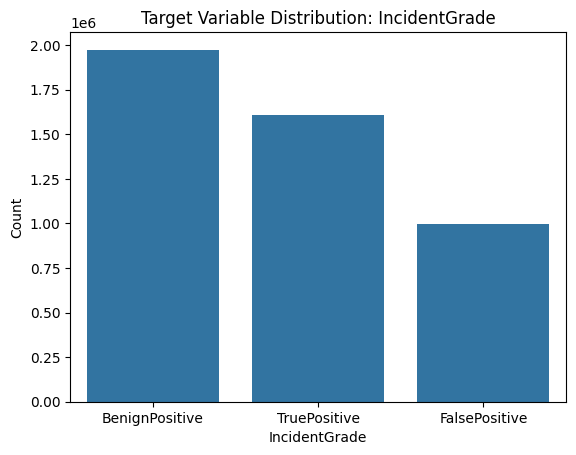

In [ ]:
sns.countplot(data=train_dataset, x='IncidentGrade', order=train_dataset['IncidentGrade'].value_counts().index)
plt.title('Target Variable Distribution: IncidentGrade')
plt.xlabel('IncidentGrade')
plt.ylabel('Count')
plt.show()

In [ ]:
train_dataset['Timestamp'] = pd.to_datetime(train_dataset['Timestamp'])
train_dataset['Year'] = train_dataset['Timestamp'].dt.year
train_dataset['Month'] = train_dataset['Timestamp'].dt.month
train_dataset['Day'] = train_dataset['Timestamp'].dt.day
train_dataset['Hour'] = train_dataset['Timestamp'].dt.hour

train_dataset.drop(columns='Timestamp',inplace=True)

In [ ]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8922805 entries, 0 to 9516836
Data columns (total 38 columns):
 #   Column              Dtype   
---  ------              -----   
 0   Id                  int64   
 1   OrgId               int16   
 2   IncidentId          int32   
 3   AlertId             int32   
 4   DetectorId          int16   
 5   AlertTitle          int32   
 6   Category            object  
 7   IncidentGrade       category
 8   EntityType          object  
 9   EvidenceRole        category
 10  DeviceId            int32   
 11  Sha256              int32   
 12  IpAddress           int32   
 13  Url                 int32   
 14  AccountSid          int32   
 15  AccountUpn          int32   
 16  AccountObjectId     int32   
 17  AccountName         int32   
 18  DeviceName          int32   
 19  NetworkMessageId    int32   
 20  RegistryKey         int16   
 21  RegistryValueName   int16   
 22  RegistryValueData   int16   
 23  ApplicationId       int16   
 24  App

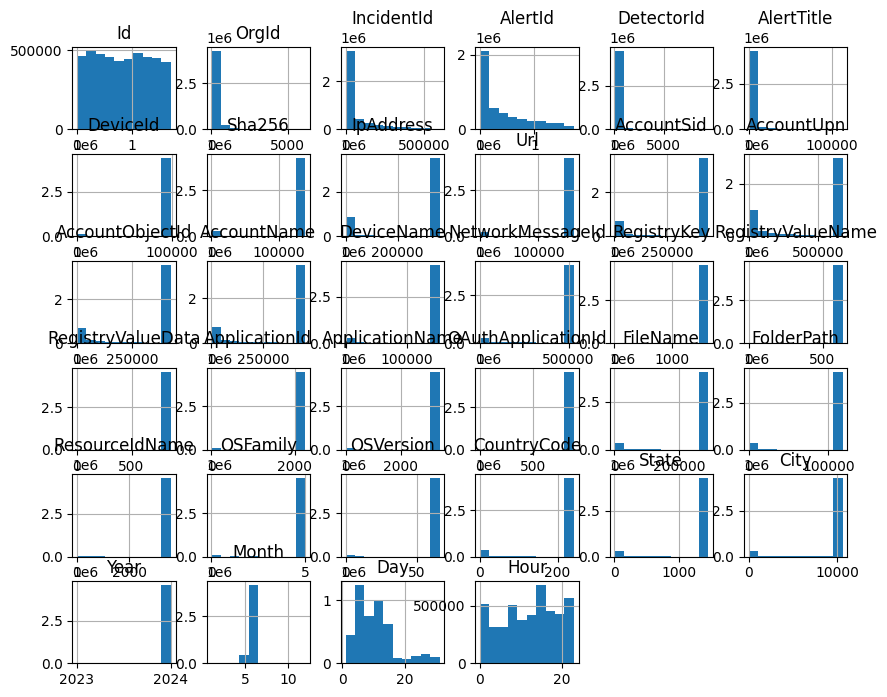

In [ ]:
train_dataset.hist(figsize=(10,8))
plt.show()

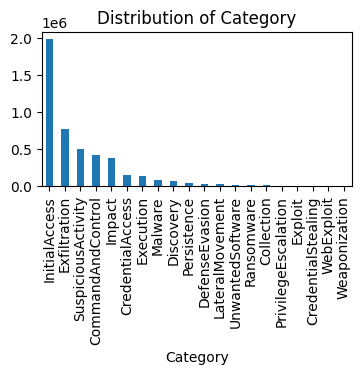

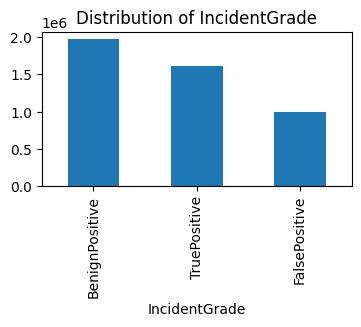

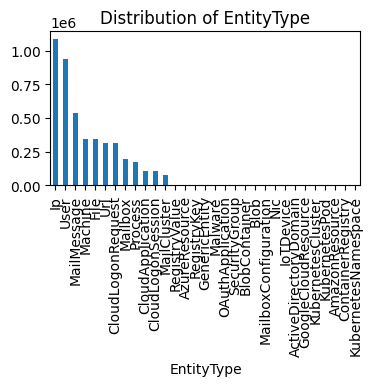

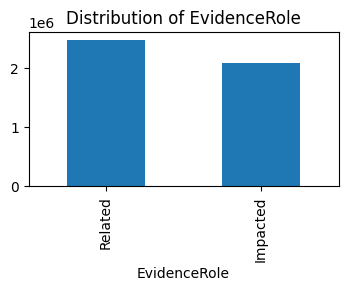

In [ ]:
categorical_columns = train_dataset.select_dtypes(include=['object','category'])

for col in categorical_columns:
    plt.figure(figsize=(4, 2))
    train_dataset[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()

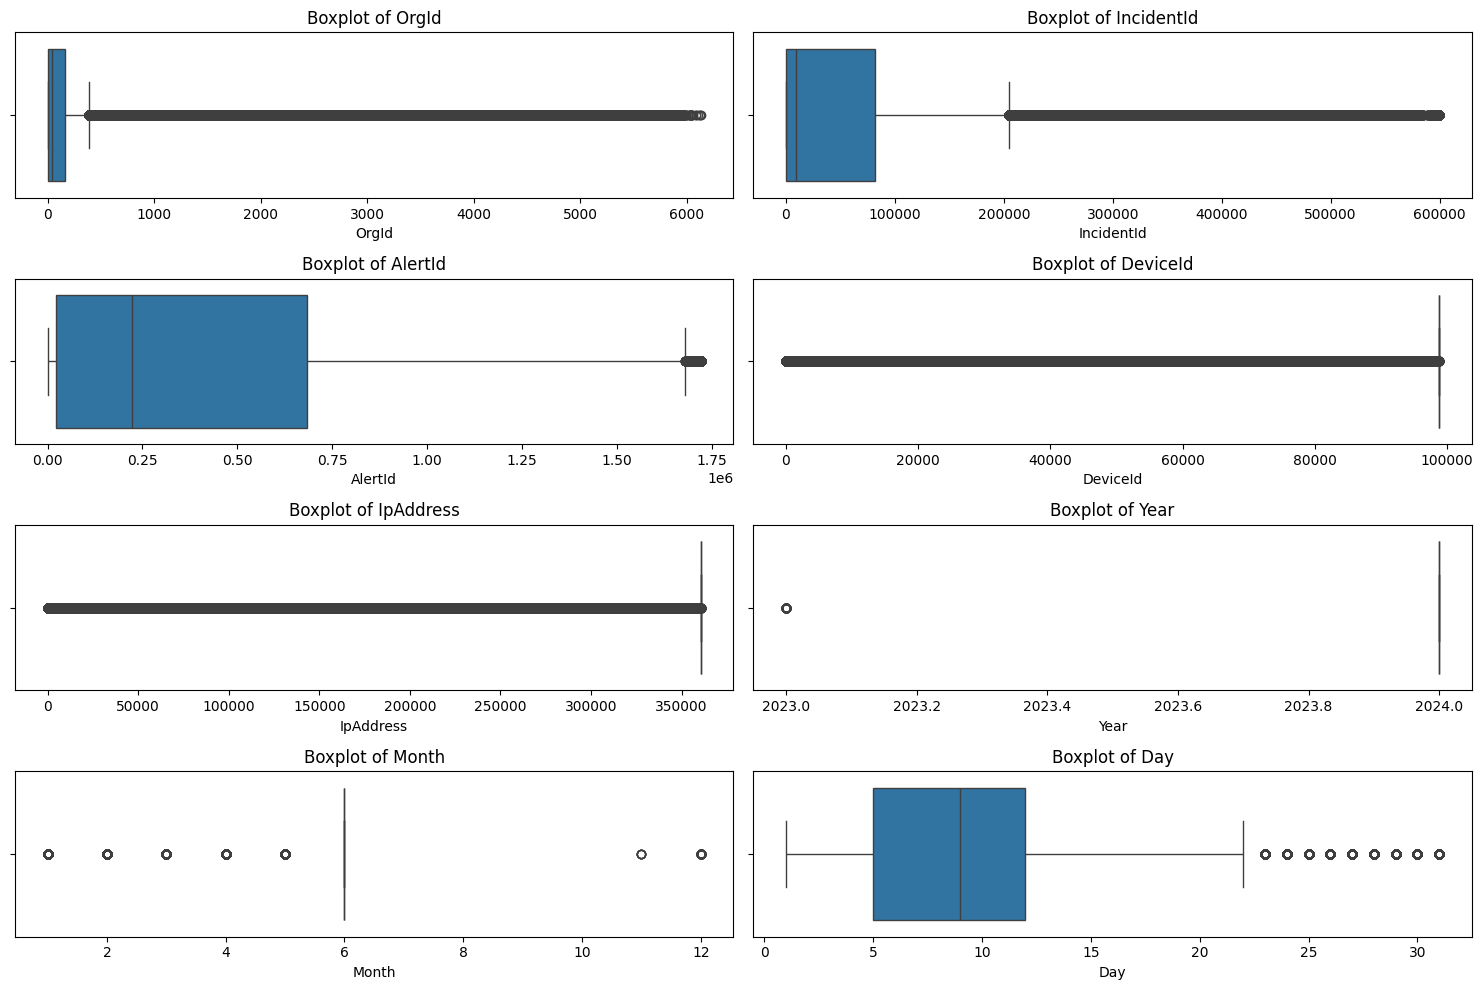

In [ ]:
numeric_cols = ['OrgId', 'IncidentId', 'AlertId', 'DeviceId', 'IpAddress', 'Year', 'Month', 'Day']
plt.figure(figsize=(15, 10))
num_plots = len(numeric_cols)
rows = (num_plots + 1) // 2

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, 2, i)
    sns.boxplot(x=train_dataset[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [ ]:
train_data1 = train_dataset.copy()

In [ ]:
numeric_columns = train_dataset.select_dtypes(include=['int8','int16', 'int32', 'int64', 'float64'])

numeric_columns.columns

Index(['Id', 'OrgId', 'IncidentId', 'AlertId', 'DetectorId', 'AlertTitle',
       'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'RegistryKey', 'RegistryValueName', 'RegistryValueData',
       'ApplicationId', 'ApplicationName', 'OAuthApplicationId', 'FileName',
       'FolderPath', 'ResourceIdName', 'OSFamily', 'OSVersion', 'CountryCode',
       'State', 'City', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')

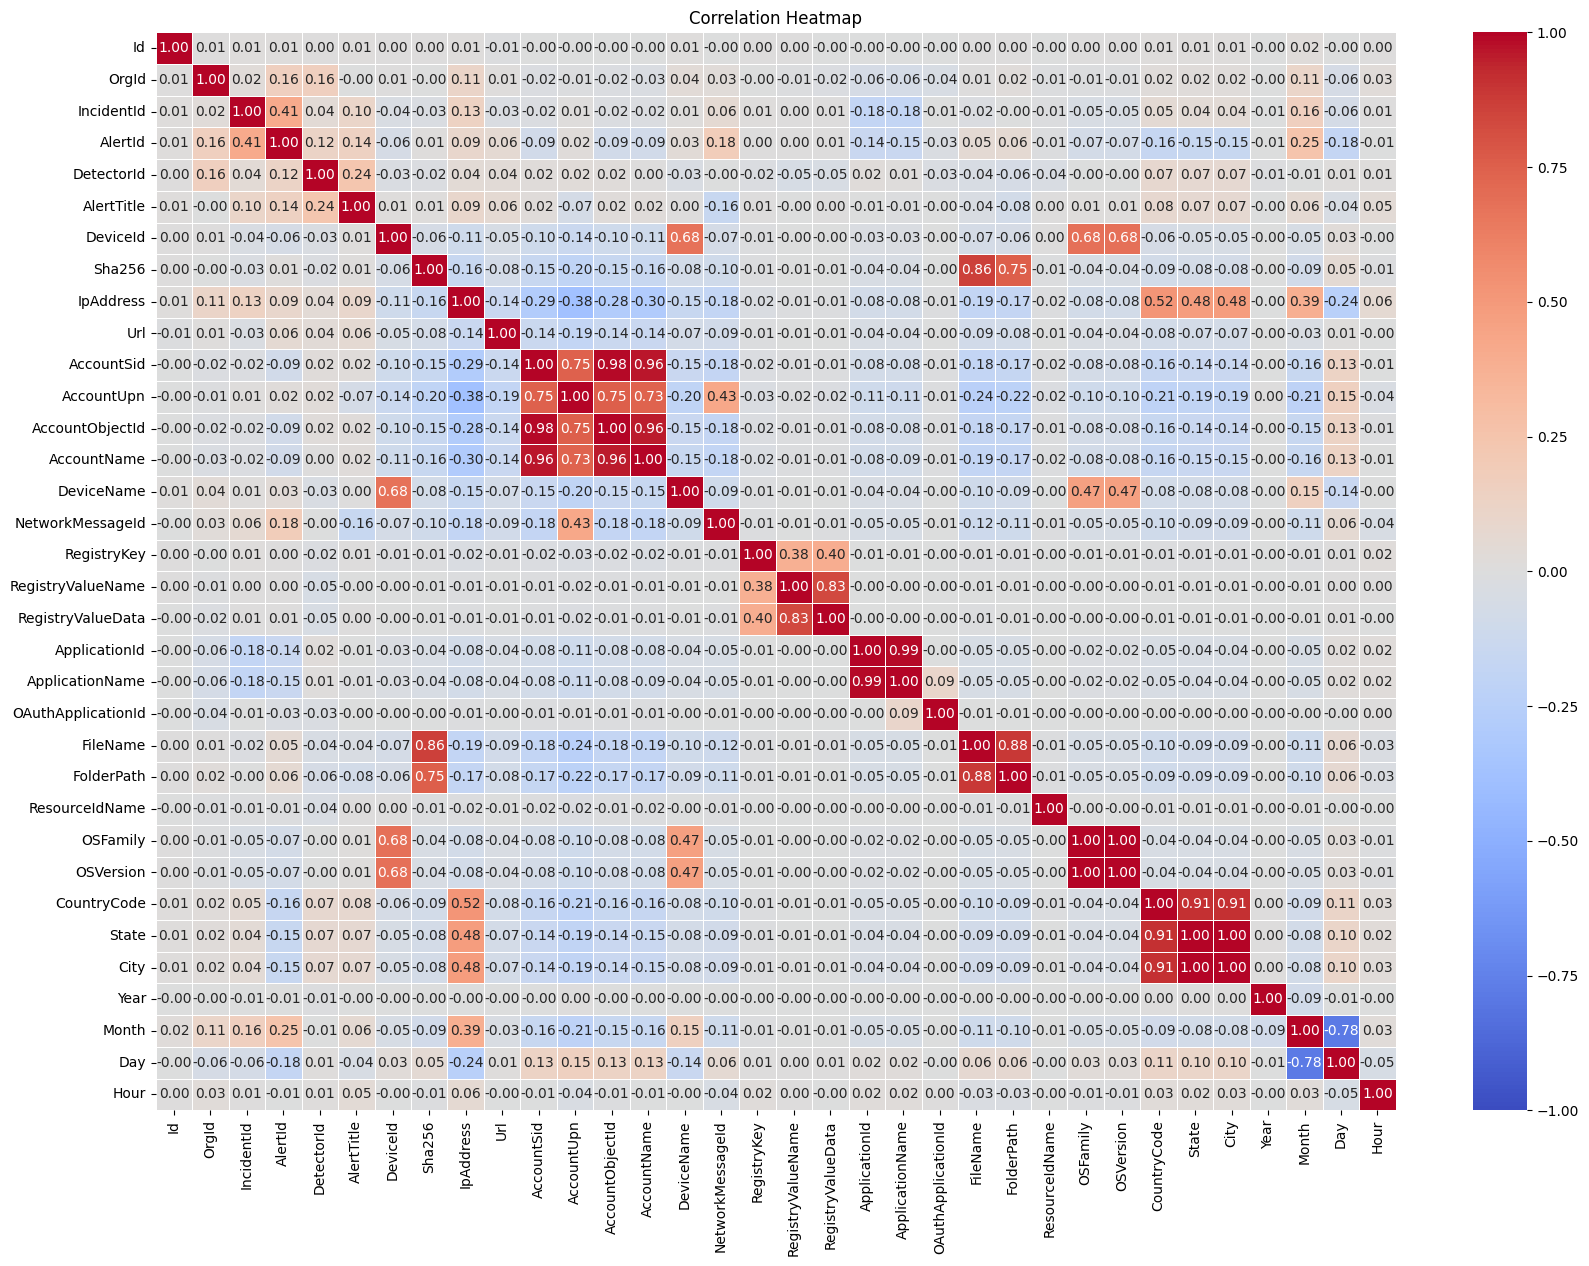

In [ ]:
plt.figure(figsize=(20, 14))
sns.heatmap(numeric_columns.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
id_columns = ['Id', 'OrgId', 'IncidentId', 'AlertId', 'DetectorId', 'DeviceId', 'Sha256',
              'IpAddress', 'Url', 'AccountSid', 'AccountUpn', 'AccountObjectId',
              'NetworkMessageId', 'RegistryKey', 'RegistryValueName',
              'RegistryValueData', 'ApplicationId', 'ApplicationName', 'OAuthApplicationId',
              'FileName', 'FolderPath', 'ResourceIdName']

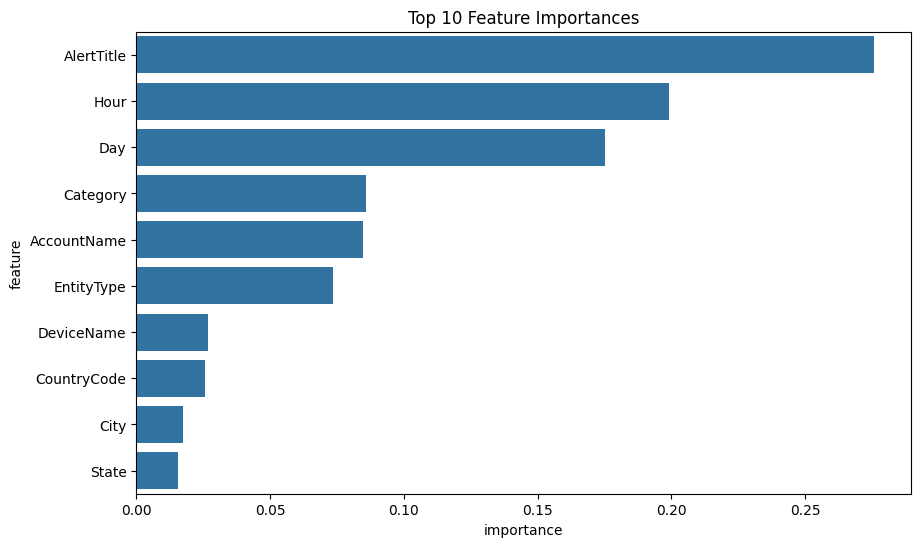

In [ ]:
train_sample = train_dataset.sample(frac=0.001, random_state=42)
X = train_sample.drop(id_columns + ['IncidentGrade'], axis=1, errors='ignore')
y = train_sample['IncidentGrade']

non_numeric_cols = X.select_dtypes(exclude=['number']).columns
le = LabelEncoder()
for col in non_numeric_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# Random Forest model
rf = RandomForestClassifier()
rf.fit(X, y)
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
feature_importances = feature_importances.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances.head(10))
plt.title('Top 10 Feature Importances')
plt.show()

In [ ]:
imp_features= [
    'Alert Title', 'Hour', 'Day', 'AccountName', 'Category', 'EntityType', 'DeviceName', 'CountryCode', 'State', 'City']

In [ ]:
print(train_dataset.columns)
train_dataset.shape

Index(['Id', 'OrgId', 'IncidentId', 'AlertId', 'DetectorId', 'AlertTitle',
       'Category', 'IncidentGrade', 'EntityType', 'EvidenceRole', 'DeviceId',
       'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'RegistryKey', 'RegistryValueName', 'RegistryValueData',
       'ApplicationId', 'ApplicationName', 'OAuthApplicationId', 'FileName',
       'FolderPath', 'ResourceIdName', 'OSFamily', 'OSVersion', 'CountryCode',
       'State', 'City', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')


(8922805, 38)

In [ ]:
train_dataset.nunique()

,0
Id,707108
OrgId,5340
IncidentId,448901
AlertId,1248789
DetectorId,7813
AlertTitle,79952
Category,20
IncidentGrade,3
EntityType,33
EvidenceRole,2


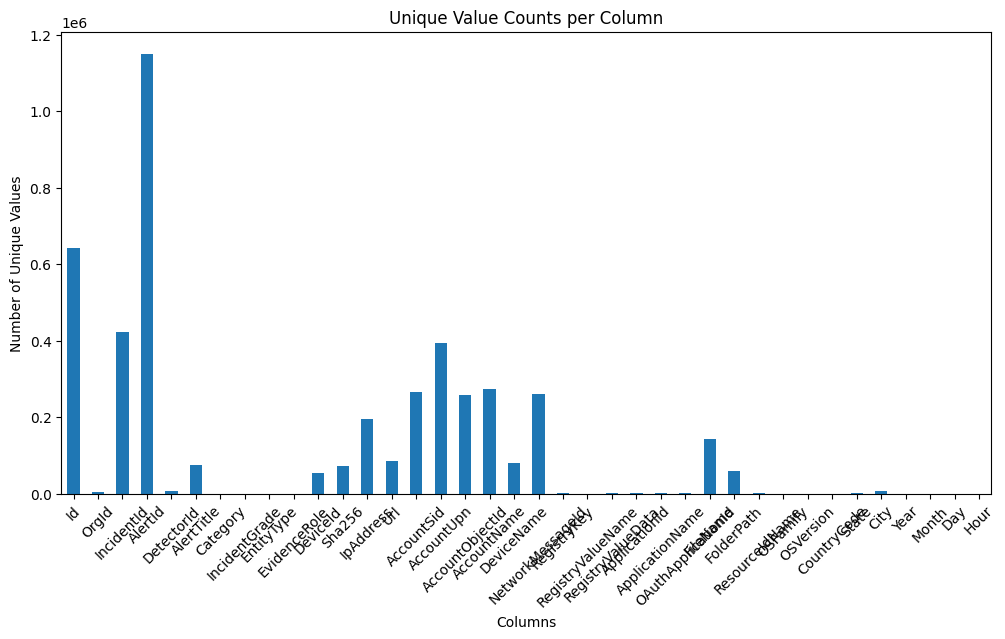

In [ ]:
unique_counts = train_dataset.nunique()
unique_counts.plot(kind='bar', figsize=(12, 6))
plt.title('Unique Value Counts per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Unique Values')
plt.xticks(rotation=45)
plt.show()

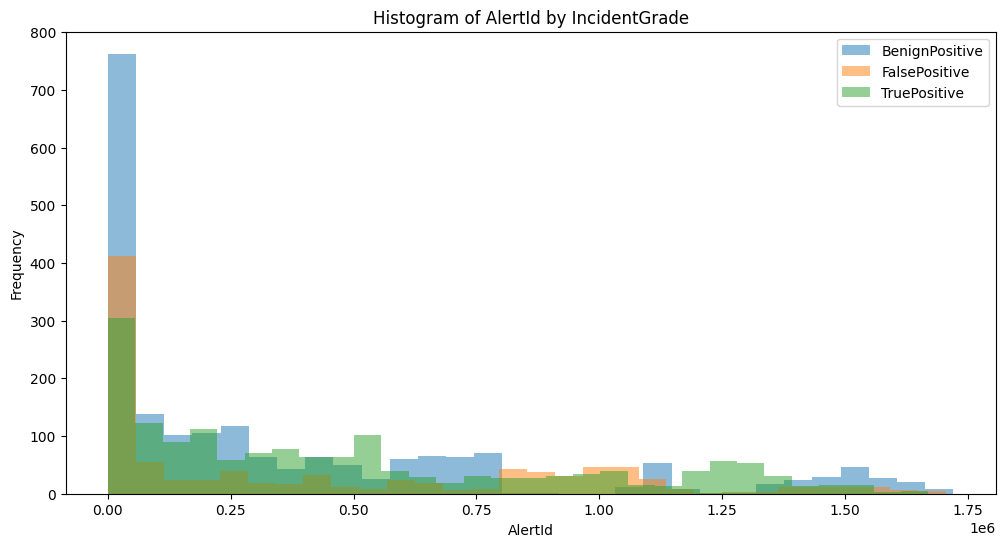

In [ ]:
train_sample = train_data1.sample(frac=0.001, random_state=42)

plt.figure(figsize=(12, 6))
for grade in train_sample['IncidentGrade'].unique():
    subset = train_sample[train_sample['IncidentGrade'] == grade]
    plt.hist(subset['AlertId'], bins=30, alpha=0.5, label=grade)

plt.xlabel('AlertId')
plt.ylabel('Frequency')
plt.title('Histogram of AlertId by IncidentGrade')
plt.legend()
plt.show()

In [ ]:
columns_to_drop = [
    'Id', 'OrgId', 'IncidentId', 'AlertId', 'DetectorId', 'DetectorId','Sha256', 'IpAddress',
    'AccountSid', 'AccountUpn', 'AccountObjectId', 'DeviceId', 'NetworkMessageId',
    'RegistryKey', 'RegistryValueName', 'RegistryValueData', 'ApplicationId', 'ApplicationName',
    'OAuthApplicationId', 'FileName', 'FolderPath', 'ResourceIdName', 'OSVersion'
]
train_dataset.drop(columns=columns_to_drop, inplace=True)

In [ ]:
print(train_dataset.columns)
train_dataset.shape

Index(['AlertTitle', 'Category', 'IncidentGrade', 'EntityType', 'EvidenceRole',
       'Url', 'AccountName', 'DeviceName', 'OSFamily', 'CountryCode', 'State',
       'City', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')


(8922805, 16)

In [ ]:
def handle_outliers(df, iqr_multiplier=3.0):
    numeric_features = df.select_dtypes(include=['int8','int16', 'int32', 'int64', 'float64'])
    for col in numeric_features.columns:
        # IQR method
        Q1 = numeric_features[col].quantile(0.25)
        Q3 = numeric_features[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        q_low = df[col].quantile(0.01)
        q_high = df[col].quantile(0.99)
        df[col] = df[col].clip(lower=q_low, upper=q_high)

    return df

In [ ]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8922805 entries, 0 to 9516836
Data columns (total 16 columns):
 #   Column         Dtype   
---  ------         -----   
 0   AlertTitle     int32   
 1   Category       object  
 2   IncidentGrade  category
 3   EntityType     object  
 4   EvidenceRole   category
 5   Url            int32   
 6   AccountName    int32   
 7   DeviceName     int32   
 8   OSFamily       int8    
 9   CountryCode    int16   
 10  State          int16   
 11  City           int16   
 12  Year           int32   
 13  Month          int32   
 14  Day            int32   
 15  Hour           int32   
dtypes: category(2), int16(3), int32(8), int8(1), object(2)
memory usage: 553.1+ MB


In [ ]:
train_dataset = handle_outliers(train_dataset, iqr_multiplier=3.0)

In [ ]:
train_dataset.shape

(8922805, 16)

In [ ]:
numeric_features = train_dataset.select_dtypes(include=['int8','int16', 'int32', 'int64', 'float64']).drop(columns=id_columns, errors='ignore')
scaler = StandardScaler()

train_dataset[numeric_features.columns] = scaler.fit_transform(numeric_features)

In [ ]:
train_dataset.shape

(8922805, 16)

In [ ]:
categorical_columns = ['AlertTitle', 'Category', 'EntityType', 'EvidenceRole',
       'Url', 'AccountName', 'DeviceName', 'OSFamily', 'CountryCode', 'State', 'City', 'Year',
       'Month', 'Day', 'Hour']

In [ ]:
columns_to_group = ['AlertTitle', 'Url', 'AccountName', 'DeviceName', 'CountryCode', 'State', 'City']

for column in columns_to_group:
    category_counts = train_dataset[column].value_counts()
    top_categories = category_counts.nlargest(5).index
    train_dataset[column] = train_dataset[column].where(train_dataset[column].isin(top_categories), 'Others')

train_dataset


,AlertTitle,Category,IncidentGrade,EntityType,EvidenceRole,Url,AccountName,DeviceName,OSFamily,CountryCode,State,City,Year,Month,Day,Hour
0,Others,InitialAccess,TruePositive,Ip,Related,160396,0.544562,0.282259,0.148117,Others,Others,-3.700097,0.004479,0.321792,-0.927990,-0.908558
1,Others,Exfiltration,FalsePositive,User,Impacted,160396,Others,0.282259,0.148117,0.300905,0.274407,0.27412,0.004479,0.321792,0.665224,-1.351876
2,Others,InitialAccess,FalsePositive,Url,Related,Others,0.544562,0.282259,0.148117,0.300905,0.274407,0.27412,0.004479,0.321792,0.505903,-1.204103
3,-0.262114,CommandAndControl,BenignPositive,Url,Related,Others,0.544562,0.282259,0.148117,0.300905,0.274407,0.27412,0.004479,0.321792,0.027938,0.569169
4,Others,Execution,TruePositive,User,Impacted,160396,Others,0.282259,0.148117,0.300905,0.274407,0.27412,0.004479,0.321792,0.824545,-1.647422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9516832,Others,InitialAccess,TruePositive,CloudLogonRequest,Related,160396,0.544562,0.282259,0.148117,0.300905,0.274407,0.27412,0.004479,0.321792,-0.290704,0.421396
9516833,-0.262114,CommandAndControl,BenignPositive,Url,Related,Others,0.544562,0.282259,0.148117,0.300905,0.274407,0.27412,0.004479,0.321792,-0.609347,-0.465240
9516834,Others,Exfiltration,BenignPositive,MailMessage,Impacted,160396,0.544562,0.282259,0.148117,0.300905,0.274407,0.27412,0.004479,0.321792,0.187260,1.455805
9516835,Others,Impact,BenignPositive,Ip,Related,160396,0.544562,0.282259,0.148117,0.300905,0.274407,0.27412,0.004479,-3.032616,1.621152,1.603578


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_dataset['IncidentGrade'] = le.fit_transform(train_dataset['IncidentGrade'])

train_dataset = pd.get_dummies(train_dataset, columns=categorical_columns, drop_first=True)

In [ ]:
train_dataset.shape

(8922805, 154)

In [ ]:
train_dataset

,IncidentGrade,AlertTitle_-0.2622036860288019,AlertTitle_-0.26211444911472,AlertTitle_-0.26202521220063807,AlertTitle_-0.2619359752865561,AlertTitle_Others,Category_CommandAndControl,Category_CredentialAccess,Category_CredentialStealing,Category_DefenseEvasion,...,Hour_0.2736235505335482,Hour_0.4213962487539915,Hour_0.5691689469744348,Hour_0.7169416451948781,Hour_0.8647143434153214,Hour_1.0124870416357648,Hour_1.160259739856208,Hour_1.3080324380766513,Hour_1.4558051362970945,Hour_1.603577834517538
0,2,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,False,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,2,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9516832,2,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
9516833,0,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9516834,0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9516835,0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:

train_dataset = train_dataset.reset_index(drop=True)

In [ ]:
train_dataset.columns

Index(['IncidentGrade', 'AlertTitle_-0.2622036860288019',
       'AlertTitle_-0.26211444911472', 'AlertTitle_-0.26202521220063807',
       'AlertTitle_-0.2619359752865561', 'AlertTitle_Others',
       'Category_CommandAndControl', 'Category_CredentialAccess',
       'Category_CredentialStealing', 'Category_DefenseEvasion',
       ...
       'Hour_0.2736235505335482', 'Hour_0.4213962487539915',
       'Hour_0.5691689469744348', 'Hour_0.7169416451948781',
       'Hour_0.8647143434153214', 'Hour_1.0124870416357648',
       'Hour_1.160259739856208', 'Hour_1.3080324380766513',
       'Hour_1.4558051362970945', 'Hour_1.603577834517538'],
      dtype='object', length=154)

In [ ]:
prefix_map = {
    'AlertTitle': 'Alert',
    'Hour': 'Hour',
    'Day': 'Day',
}

# Initialize counters for each general group
counter = {v: 1 for v in prefix_map.values()}

# Build the new column list
new_columns = []
for col in train_dataset.columns:
    renamed = False
    for old_prefix, new_prefix in prefix_map.items():
        if col.startswith(old_prefix + '_'):  # match only exact prefix + underscore
            new_columns.append(f"{new_prefix}_{counter[new_prefix]}")
            counter[new_prefix] += 1
            renamed = True
            break
    if not renamed:
        new_columns.append(col)  # keep unchanged

# Apply new column names
train_dataset.columns = new_columns

In [ ]:
train_dataset

,IncidentGrade,Alert_1,Alert_2,Alert_3,Alert_4,Alert_5,Category_CommandAndControl,Category_CredentialAccess,Category_CredentialStealing,Category_DefenseEvasion,...,Hour_14,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23
0,2,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,False,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,2,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8922800,2,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
8922801,0,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8922802,0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
8922803,0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
joblib.dump(train_dataset, 'encoded_train_data.joblib')

['encoded_train_data.joblib']

In [ ]:
train_dataset = joblib.load('encoded_train_data.joblib')

In [ ]:
train_dataset.head()

,IncidentGrade,Alert_1,Alert_2,Alert_3,Alert_4,Alert_5,Category_CommandAndControl,Category_CredentialAccess,Category_CredentialStealing,Category_DefenseEvasion,...,Hour_14,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23
0,2,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,False,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,2,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
print(train_dataset.memory_usage(deep=True).sum() / (1024 ** 2), "MB")

1370.0215692520142 MB


In [ ]:
train_dataset.to_csv("final_train_data.csv", index=False)



In [ ]:
train_dataset=pd.read_csv("final_train_data.csv")

In [ ]:
test_zip = '/content/GUIDE_Test.csv.zip'
with zipfile.ZipFile(test_zip, 'r') as zip_ref:
     zip_ref.extractall()

In [ ]:
def optimize_memory(df):
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')
    return df

In [ ]:
chunks = []
test_dataset = "/content/GUIDE_Test.csv"
for chunk in pd.read_csv(test_dataset, chunksize=500000,low_memory=False):
    chunk = optimize_memory(chunk)
    chunks.append(chunk)

test_data = pd.concat(chunks, ignore_index=True)

del chunks

In [ ]:
test_data

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City,Usage
0,1245540519230,657,11767,87199,2024-06-04T22:56:27.000Z,524,563,LateralMovement,T1021;T1047;T1105;T1569.002,BenignPositive,...,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630,Private
1,1400159342154,3,91158,632273,2024-06-03T12:58:26.000Z,2,2,CommandAndControl,NaN,BenignPositive,...,NaN,0,0,NaN,Suspicious,Suspicious,242,1445,10630,Public
2,1279900255923,145,32247,131719,2024-06-08T03:20:49.000Z,2932,10807,LateralMovement,T1021;T1027.002;T1027.005;T1105,BenignPositive,...,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630,Public
3,60129547292,222,15294,917686,2024-06-12T12:07:31.000Z,0,0,InitialAccess,T1078;T1078.004,FalsePositive,...,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public
4,515396080539,363,7615,5944,2024-06-06T17:42:05.000Z,27,18,Discovery,T1087;T1087.002,BenignPositive,...,Suspicious,5,66,NaN,NaN,NaN,242,1445,10630,Public
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4147987,541165881145,262,3017,227156,2024-06-04T03:53:15.000Z,139,120,InitialAccess,T1566.002,BenignPositive,...,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public
4147988,438086666953,1323,31001,304819,2024-06-04T19:32:19.000Z,219,196,InitialAccess,NaN,BenignPositive,...,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Private
4147989,1297080124487,47,3653,7243,2024-06-15T00:50:22.000Z,57,29,CommandAndControl,T1046;T1071;T1210,FalsePositive,...,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Public
4147990,627065226886,70,4243,19142,2024-06-11T16:18:12.000Z,1,1,InitialAccess,T1566.002,BenignPositive,...,NaN,5,66,NaN,NaN,NaN,242,1445,10630,Private


In [ ]:
print(test_data.shape)

(4147992, 46)


In [ ]:
train_columns = set(train_dataset.columns)
test_columns = set(test_data.columns)

# Difference columns
print("Columns in Train but not in Test:", train_columns - test_columns)
print("Columns in Test but not in Train:", test_columns - train_columns)


Columns in Train but not in Test: {'Url_Others', 'City_-3.7004707785343927', 'Day_30', 'Hour_19', 'EntityType_GenericEntity', 'EntityType_User', 'Month_-9.741432059080132', 'Hour_23', 'EntityType_Mailbox', 'Day_27', 'AccountName_-2.0725764061139986', 'Hour_16', 'Category_Malware', 'Category_Persistence', 'Alert_4', 'Category_WebExploit', 'Day_20', 'Category_Exploit', 'EntityType_MailMessage', 'EntityType_Process', 'State_Others', 'CountryCode_-3.3925310940332203', 'Category_CredentialStealing', 'Hour_2', 'Category_Ransomware', 'CountryCode_Others', 'Category_LateralMovement', 'OSFamily_-4.008941265231325', 'Month_-6.387024086326022', 'Month_-13.095840031834244', 'Day_17', 'Hour_21', 'Url_160396', 'AccountName_Others', 'Category_UnwantedSoftware', 'EntityType_Nic', 'Year_0.004478990789108215', 'AccountName_-2.0725821797150807', 'Month_17.09383172295275', 'OSFamily_-1.2375689977941504', 'Day_14', 'Day_6', 'EntityType_Container', 'Day_24', 'EntityType_CloudApplication', 'Day_11', 'EntityT

In [ ]:
print(train_dataset[list(train_columns - test_columns)].head())
print(test_data[list(test_columns - train_columns)].head())

   Url_Others  City_-3.7004707785343927  Day_30  Hour_19  \
0       False                     False   False    False   
1       False                     False   False    False   
2        True                     False   False    False   
3        True                     False   False    False   
4       False                     False   False    False   

   EntityType_GenericEntity  EntityType_User  Month_-9.741432059080132  \
0                     False            False                     False   
1                     False             True                     False   
2                     False            False                     False   
3                     False            False                     False   
4                     False             True                     False   

   Hour_23  EntityType_Mailbox  Day_27  ...  City_Others  Hour_3  Day_15  \
0    False               False   False  ...        False   False   False   
1    False               False   False  ..

In [ ]:
print("Target column in Train:", 'IncidentGrade' in train_dataset.columns)
print("Target column in Test:", 'IncidentGrade' in test_data.columns)

Target column in Train: True
Target column in Test: True


In [ ]:
test_data.drop(columns='Usage',inplace=True)
test_data.shape[1]

45

In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4147992 entries, 0 to 4147991
Data columns (total 45 columns):
 #   Column              Dtype   
---  ------              -----   
 0   Id                  int64   
 1   OrgId               int16   
 2   IncidentId          int32   
 3   AlertId             int32   
 4   Timestamp           object  
 5   DetectorId          int16   
 6   AlertTitle          int32   
 7   Category            object  
 8   MitreTechniques     object  
 9   IncidentGrade       category
 10  ActionGrouped       category
 11  ActionGranular      object  
 12  EntityType          object  
 13  EvidenceRole        category
 14  DeviceId            int32   
 15  Sha256              int32   
 16  IpAddress           int32   
 17  Url                 int32   
 18  AccountSid          int32   
 19  AccountUpn          int32   
 20  AccountObjectId     int32   
 21  AccountName         int32   
 22  DeviceName          int32   
 23  NetworkMessageId    int32   
 24

In [ ]:
test_data.describe()

,Id,OrgId,IncidentId,AlertId,DetectorId,AlertTitle,DeviceId,Sha256,IpAddress,Url,...,ApplicationName,OAuthApplicationId,FileName,FolderPath,ResourceIdName,OSFamily,OSVersion,CountryCode,State,City
count,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,...,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06,4.147992e+06
mean,8.462250e+11,1.756698e+02,6.780345e+04,4.072191e+05,1.008391e+02,2.529514e+03,9.575061e+04,1.283939e+05,2.873898e+05,1.504279e+05,...,3.342993e+03,8.808119e+02,2.618998e+05,1.074020e+05,3.583541e+03,4.899529e+00,6.466873e+01,2.222218e+02,1.344570e+03,9.883839e+03
std,4.923351e+11,3.708729e+02,1.178736e+05,4.550578e+05,4.082934e+02,1.044138e+04,1.615628e+04,3.457595e+04,1.400920e+05,3.734754e+04,...,5.096996e+02,1.238317e+01,8.208434e+04,3.260346e+04,9.012124e+01,7.001299e-01,9.269678e+00,6.499822e+01,3.626851e+02,2.696302e+03
min,1.000000e+00,0.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.209068e+11,8.000000e+00,4.110000e+02,2.365900e+04,2.000000e+00,2.000000e+00,9.879900e+04,1.382680e+05,3.606060e+05,1.603960e+05,...,3.421000e+03,8.810000e+02,2.895730e+05,1.176680e+05,3.586000e+03,5.000000e+00,6.600000e+01,2.420000e+02,1.445000e+03,1.063000e+04
50%,8.418136e+11,4.300000e+01,8.818000e+03,2.228970e+05,7.000000e+00,9.000000e+00,9.879900e+04,1.382680e+05,3.606060e+05,1.603960e+05,...,3.421000e+03,8.810000e+02,2.895730e+05,1.176680e+05,3.586000e+03,5.000000e+00,6.600000e+01,2.420000e+02,1.445000e+03,1.063000e+04
75%,1.271310e+12,1.730000e+02,7.944000e+04,6.711010e+05,3.900000e+01,1.160000e+02,9.879900e+04,1.382680e+05,3.606060e+05,1.603960e+05,...,3.421000e+03,8.810000e+02,2.895730e+05,1.176680e+05,3.586000e+03,5.000000e+00,6.600000e+01,2.420000e+02,1.445000e+03,1.063000e+04
max,1.709397e+12,6.138000e+03,5.997000e+05,1.721457e+06,9.520000e+03,1.131690e+05,9.879900e+04,1.382680e+05,3.606060e+05,1.603960e+05,...,3.421000e+03,8.810000e+02,2.895730e+05,1.176680e+05,3.586000e+03,5.000000e+00,6.600000e+01,2.420000e+02,1.445000e+03,1.063000e+04


In [ ]:
test_data.isnull().sum()

,0
Id,0
OrgId,0
IncidentId,0
AlertId,0
Timestamp,0
DetectorId,0
AlertTitle,0
Category,0
MitreTechniques,2307104
IncidentGrade,0


In [ ]:
missing_percentage = test_data.isnull().mean() * 100
columns_to_drop = missing_percentage[missing_percentage > 50].index
test_data.drop(columns=columns_to_drop, axis=1, inplace=True)
print(f"Columns dropped due to >50% missing values: {columns_to_drop.tolist()}")

Columns dropped due to >50% missing values: ['MitreTechniques', 'ActionGrouped', 'ActionGranular', 'EmailClusterId', 'ThreatFamily', 'ResourceType', 'Roles', 'AntispamDirection', 'SuspicionLevel', 'LastVerdict']


In [ ]:
test_data.isnull().sum()

,0
Id,0
OrgId,0
IncidentId,0
AlertId,0
Timestamp,0
DetectorId,0
AlertTitle,0
Category,0
IncidentGrade,0
EntityType,0


In [ ]:
test_data.duplicated().sum()

np.int64(225297)

In [ ]:
test_data = test_data.drop_duplicates()

print(f"Number of rows after removing duplicates: {test_data.shape[0]}")

Number of rows after removing duplicates: 3922695


In [ ]:
print("Target variable distribution:")
test_data['IncidentGrade'].value_counts()

Target variable distribution:


,count
IncidentGrade,
BenignPositive,1630942
TruePositive,1422856
FalsePositive,868897


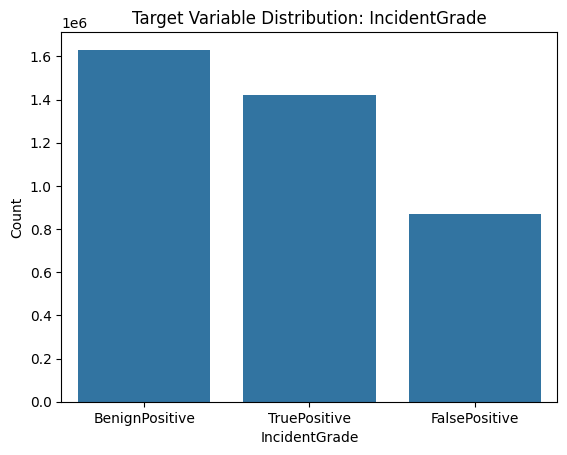

In [ ]:
sns.countplot(data=test_data, x='IncidentGrade', order=test_data['IncidentGrade'].value_counts().index)
plt.title('Target Variable Distribution: IncidentGrade')
plt.xlabel('IncidentGrade')
plt.ylabel('Count')
plt.show()

In [ ]:
test_data['Timestamp'] = pd.to_datetime(test_data['Timestamp'])
test_data['Year'] = test_data['Timestamp'].dt.year
test_data['Month'] = test_data['Timestamp'].dt.month
test_data['Day'] = test_data['Timestamp'].dt.day
test_data['Hour'] = test_data['Timestamp'].dt.hour

test_data.drop(columns='Timestamp',inplace=True)

In [ ]:
test_data.columns

Index(['Id', 'OrgId', 'IncidentId', 'AlertId', 'DetectorId', 'AlertTitle',
       'Category', 'IncidentGrade', 'EntityType', 'EvidenceRole', 'DeviceId',
       'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'RegistryKey', 'RegistryValueName', 'RegistryValueData',
       'ApplicationId', 'ApplicationName', 'OAuthApplicationId', 'FileName',
       'FolderPath', 'ResourceIdName', 'OSFamily', 'OSVersion', 'CountryCode',
       'State', 'City', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')

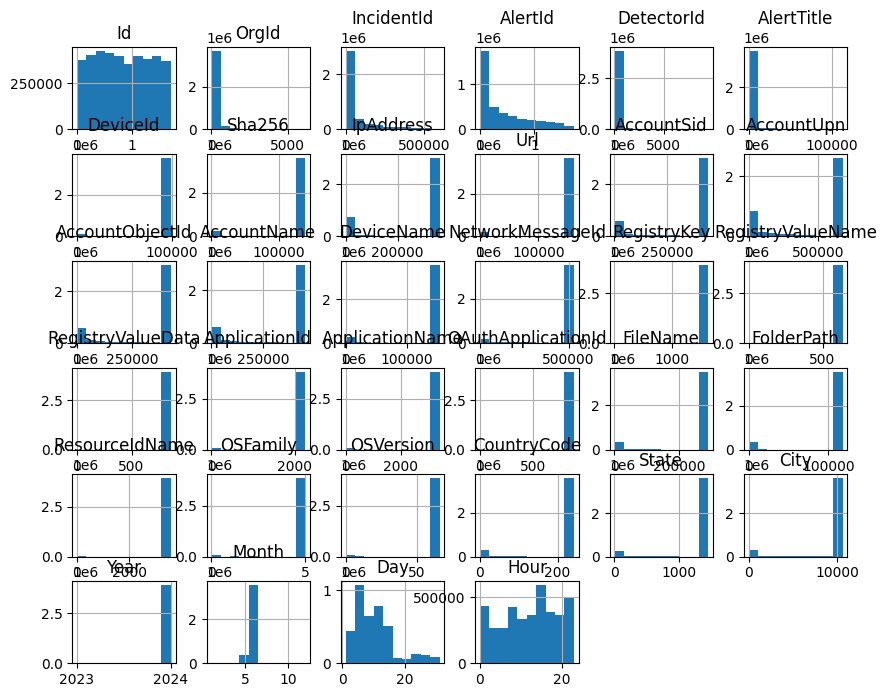

In [ ]:
test_data.hist(figsize=(10,8))
plt.show()

In [ ]:
numeric_columns = test_data.select_dtypes(include=['int8','int16', 'int32', 'int64', 'float64'])

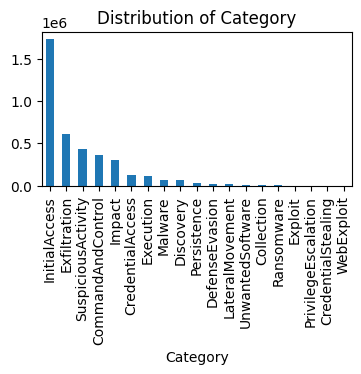

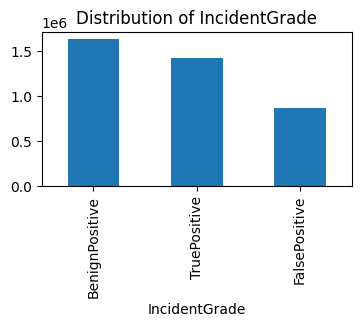

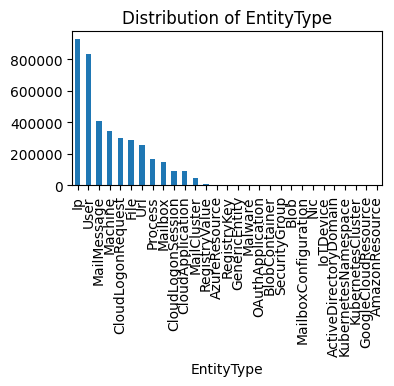

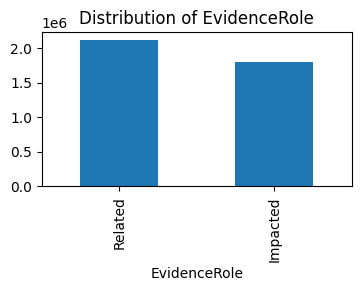

In [ ]:
categorical_columns = test_data.select_dtypes(include=['object','category'])

for col in categorical_columns:
    plt.figure(figsize=(4, 2))
    test_data[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()

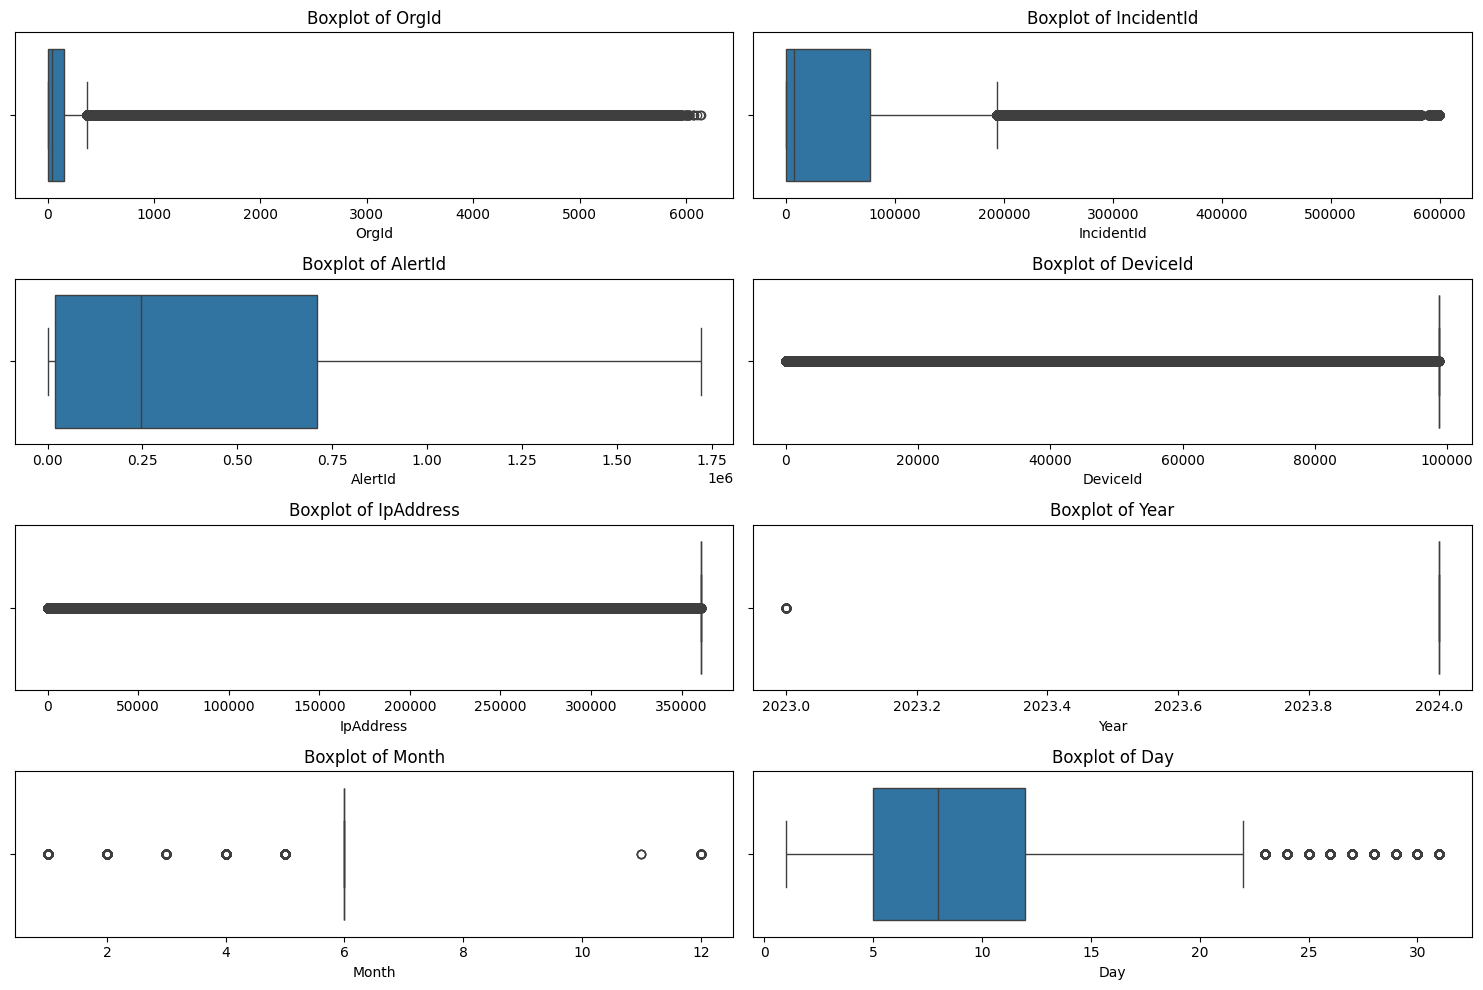

In [ ]:
numeric_cols = ['OrgId', 'IncidentId', 'AlertId', 'DeviceId', 'IpAddress', 'Year', 'Month', 'Day']
plt.figure(figsize=(15, 10))
num_plots = len(numeric_cols)
rows = (num_plots + 1) // 2

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, 2, i)
    sns.boxplot(x=test_data[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

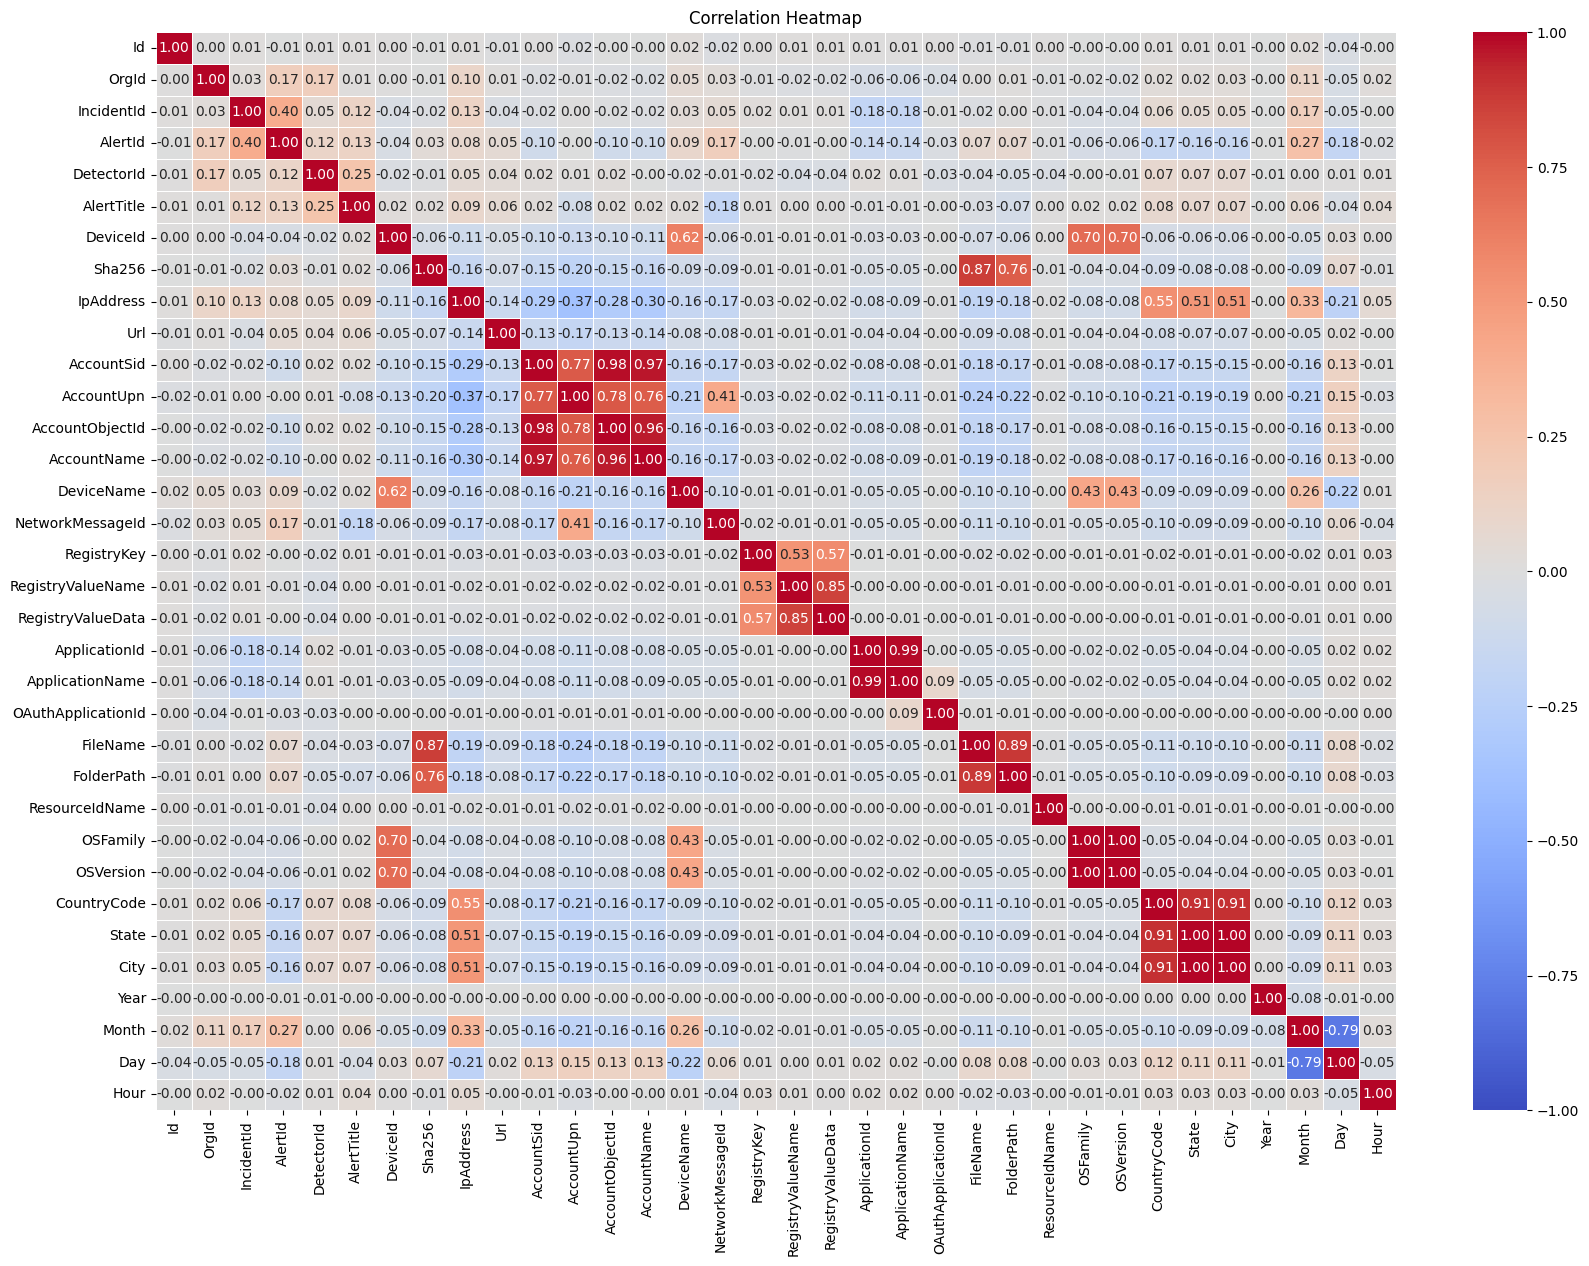

In [ ]:
plt.figure(figsize=(20, 14))
sns.heatmap(numeric_columns.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

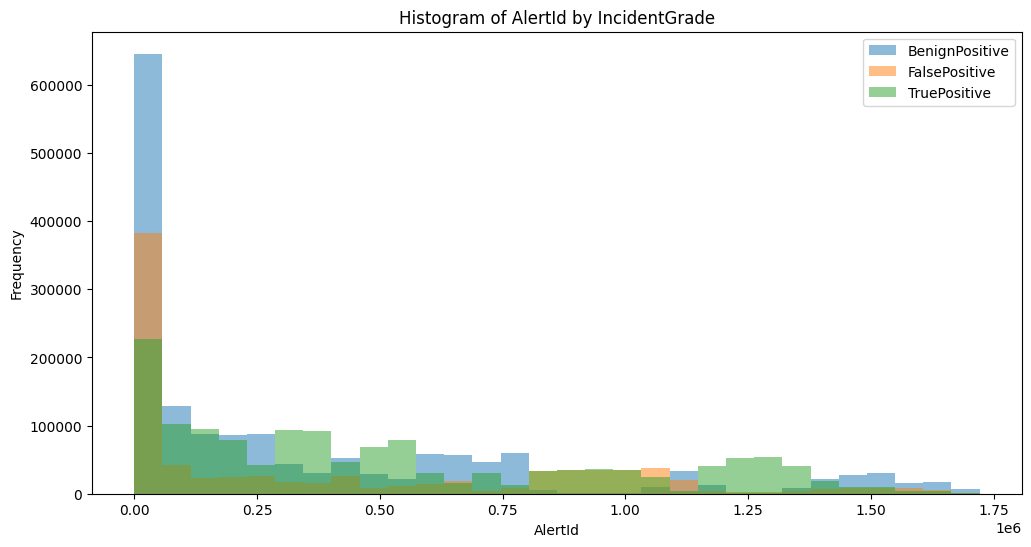

In [ ]:
plt.figure(figsize=(12, 6))
for grade in test_data['IncidentGrade'].unique():
    subset = test_data[test_data['IncidentGrade'] == grade]
    plt.hist(subset['AlertId'], bins=30, alpha=0.5, label=grade)

plt.xlabel('AlertId')
plt.ylabel('Frequency')
plt.title('Histogram of AlertId by IncidentGrade')
plt.legend()
plt.show()

In [ ]:
print(test_data.columns)
len(test_data.columns)

Index(['Id', 'OrgId', 'IncidentId', 'AlertId', 'DetectorId', 'AlertTitle',
       'Category', 'IncidentGrade', 'EntityType', 'EvidenceRole', 'DeviceId',
       'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'RegistryKey', 'RegistryValueName', 'RegistryValueData',
       'ApplicationId', 'ApplicationName', 'OAuthApplicationId', 'FileName',
       'FolderPath', 'ResourceIdName', 'OSFamily', 'OSVersion', 'CountryCode',
       'State', 'City', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')


38

In [ ]:
columns_to_drop = [
    'Id', 'OrgId', 'IncidentId', 'AlertId', 'DetectorId', 'DetectorId','Sha256', 'IpAddress',
    'AccountSid', 'AccountUpn', 'AccountObjectId', 'DeviceId', 'NetworkMessageId',
    'RegistryKey', 'RegistryValueName', 'RegistryValueData', 'ApplicationId', 'ApplicationName',
    'OAuthApplicationId', 'FileName', 'FolderPath', 'ResourceIdName', 'OSVersion'
]
test_data.drop(columns=columns_to_drop, inplace=True)

In [ ]:
id_columns = ['Id', 'OrgId', 'IncidentId', 'AlertId', 'DetectorId', 'DeviceId', 'Sha256',
              'IpAddress', 'Url', 'AccountSid', 'AccountUpn', 'AccountObjectId',
              'NetworkMessageId', 'RegistryKey', 'RegistryValueName',
              'RegistryValueData', 'ApplicationId', 'ApplicationName', 'OAuthApplicationId',
              'FileName', 'FolderPath', 'ResourceIdName']

In [ ]:
test_data.shape

(3922695, 16)

In [ ]:
numeric_features = test_data.select_dtypes(include=['number']).drop(columns=id_columns, errors='ignore')

scaler = StandardScaler()

test_data[numeric_features.columns] = scaler.fit_transform(numeric_features)

In [ ]:
test_data

,AlertTitle,Category,IncidentGrade,EntityType,EvidenceRole,Url,AccountName,DeviceName,OSFamily,CountryCode,State,City,Year,Month,Day,Hour
0,-0.196898,LateralMovement,BenignPositive,User,Impacted,160396,-2.059020,0.302300,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,-0.900146,1.448344
1,-0.249243,CommandAndControl,BenignPositive,Machine,Impacted,160396,0.545146,-3.484561,-6.801965,0.313739,0.285377,0.285198,0.003878,0.326831,-1.058347,-0.033812
2,0.758939,LateralMovement,BenignPositive,Process,Related,160396,0.545146,0.302300,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,-0.267343,-1.367753
3,-0.249430,InitialAccess,FalsePositive,CloudLogonSession,Related,160396,0.545146,0.302300,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,0.365461,-0.033812
4,-0.247750,Discovery,BenignPositive,User,Impacted,160396,-1.280586,0.302300,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,-0.583744,0.707266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4147985,0.433764,Malware,BenignPositive,Machine,Impacted,160396,0.545146,-3.555862,-6.801965,0.313739,0.285377,0.285198,0.003878,0.326831,-1.058347,1.151913
4147987,-0.238233,InitialAccess,BenignPositive,User,Impacted,160396,-1.980141,0.302300,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,-0.900146,-1.367753
4147988,-0.231141,InitialAccess,BenignPositive,User,Impacted,160396,-1.447236,0.302300,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,-0.900146,1.003697
4147989,-0.246724,CommandAndControl,FalsePositive,Ip,Related,160396,0.545146,0.302300,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,0.840063,-1.812400


In [ ]:
categorical_columns = ['AlertTitle', 'Category', 'EntityType', 'EvidenceRole',
       'Url', 'AccountName', 'DeviceName', 'OSFamily', 'CountryCode', 'State', 'City', 'Year',
       'Month', 'Day', 'Hour']

In [ ]:
columns_to_group = ['AlertTitle', 'Url', 'AccountName', 'DeviceName', 'CountryCode', 'State', 'City']

for column in columns_to_group:
    category_counts = test_data[column].value_counts()
    top_categories = category_counts.nlargest(5).index
    test_data[column] = test_data[column].where(test_data[column].isin(top_categories), 'Others')
test_data

,AlertTitle,Category,IncidentGrade,EntityType,EvidenceRole,Url,AccountName,DeviceName,OSFamily,CountryCode,State,City,Year,Month,Day,Hour
0,Others,LateralMovement,BenignPositive,User,Impacted,160396,Others,0.3023,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,-0.900146,1.448344
1,-0.249243,CommandAndControl,BenignPositive,Machine,Impacted,160396,0.545146,Others,-6.801965,0.313739,0.285377,0.285198,0.003878,0.326831,-1.058347,-0.033812
2,Others,LateralMovement,BenignPositive,Process,Related,160396,0.545146,0.3023,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,-0.267343,-1.367753
3,-0.24943,InitialAccess,FalsePositive,CloudLogonSession,Related,160396,0.545146,0.3023,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,0.365461,-0.033812
4,Others,Discovery,BenignPositive,User,Impacted,160396,Others,0.3023,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,-0.583744,0.707266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4147985,Others,Malware,BenignPositive,Machine,Impacted,160396,0.545146,-3.555862,-6.801965,0.313739,0.285377,0.285198,0.003878,0.326831,-1.058347,1.151913
4147987,Others,InitialAccess,BenignPositive,User,Impacted,160396,Others,0.3023,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,-0.900146,-1.367753
4147988,Others,InitialAccess,BenignPositive,User,Impacted,160396,Others,0.3023,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,-0.900146,1.003697
4147989,Others,CommandAndControl,FalsePositive,Ip,Related,160396,0.545146,0.3023,0.147640,0.313739,0.285377,0.285198,0.003878,0.326831,0.840063,-1.812400


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
test_data['IncidentGrade'] = le.fit_transform(test_data['IncidentGrade'])


test_data = pd.get_dummies(test_data, columns=categorical_columns, drop_first=True)

In [ ]:
test_data

,IncidentGrade,AlertTitle_-0.24933623125825694,AlertTitle_-0.2492429243139386,AlertTitle_-0.2491496173696203,AlertTitle_-0.249056310425302,AlertTitle_Others,Category_CommandAndControl,Category_CredentialAccess,Category_CredentialStealing,Category_DefenseEvasion,...,Hour_0.2626188629527248,Hour_0.4108345037435305,Hour_0.5590501445343361,Hour_0.7072657853251417,Hour_0.8554814261159474,Hour_1.003697066906753,Hour_1.1519127076975586,Hour_1.3001283484883643,Hour_1.4483439892791699,Hour_1.5965596300699756
0,0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,False,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4147985,0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4147987,0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4147988,0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4147989,1,False,False,False,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
print(train_dataset.shape)
print(test_data.shape)

(8922805, 154)
(3922695, 148)


In [ ]:
train_dataset, test_data = train_dataset.align(test_data, join='left', axis=1)
test_data.fillna(0, inplace=True)

In [ ]:
test_data.shape

(3922695, 154)

In [ ]:

test_data = test_data.reset_index(drop=True)

In [ ]:

# Saveing the data using Joblib
joblib.dump(test_data, 'encoded_test_data.joblib')

['encoded_test_data.joblib']

In [ ]:
test_data = joblib.load('encoded_test_data.joblib')

In [ ]:
test_data.head()

,IncidentGrade,Alert_1,Alert_2,Alert_3,Alert_4,Alert_5,Category_CommandAndControl,Category_CredentialAccess,Category_CredentialStealing,Category_DefenseEvasion,...,Hour_14,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23
0,0,0.0,0.0,0.0,0.0,0.0,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0.0,0.0,0.0,0.0,True,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0.0,0.0,0.0,0.0,0.0,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0.0,0.0,0.0,0.0,0.0,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0.0,0.0,0.0,0.0,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
!pip install xgboost
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.7/291.7 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 38.9 MB/s eta 0:00:00


In [ ]:
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 5.6 MB/s eta 0:00:00


In [ ]:
import joblib
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

In [ ]:
train_dataset = joblib.load('encoded_train_data.joblib', mmap_mode='r')
test_data = joblib.load('encoded_test_data.joblib', mmap_mode='r')

X = train_dataset.drop(columns=['IncidentGrade'])
y = train_dataset['IncidentGrade']

# Spliting the data (80:20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train_subsample = X_train.sample(frac=0.1, random_state=42)
y_train_subsample = y_train.loc[X_train_subsample.index]

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_jobs=-1, random_state=42),
    'LightGBM': LGBMClassifier(n_jobs=-1, random_state=42),
}

for model_name, model in models.items():
    print(f'Model: {model_name}')

    model.fit(X_train_subsample, y_train_subsample)

    y_pred = model.predict(X_val)

    # Evaluateing the models
    accuracy = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred)

    # Displaying the results of the modles
    print(f'Accuracy: {accuracy}')
    print('Classification Report:')
    print(report)
    print('Confusion Matrix:')
    print(cm)
    print('-' * 50)





Model: Logistic Regression
Accuracy: 0.6335490913451544
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.87      0.71    765560
           1       0.64      0.16      0.26    390976
           2       0.70      0.64      0.67    628025

    accuracy                           0.63   1784561
   macro avg       0.65      0.56      0.55   1784561
weighted avg       0.64      0.63      0.60   1784561

Confusion Matrix:
[[667840  21867  75853]
 [234155  63332  93489]
 [214680  13910 399435]]
--------------------------------------------------
Model: Random Forest
Accuracy: 0.701326544735652
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.84      0.75    765560
           1       0.67      0.44      0.53    390976
           2       0.75      0.70      0.72    628025

    accuracy                           0.70   1784561
   macro avg       0.70      0.66      0.67   1784561


In [ ]:
report = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting'],
    'Accuracy': [0.6318, 0.7005, 0.7011, 0.6777, 0.6756, 0.6414],
    'Macro-F1 Score': [0.54, 0.67, 0.67, 0.62, 0.61, 0.55],
    'Precision': [0.64, 0.70, 0.70, 0.71, 0.72, 0.69],
    'Recall': [0.55, 0.66, 0.66, 0.61, 0.61, 0.56]
}

df = pd.DataFrame(report)

print("Comparison Table:")
print(df.to_string(index=False))

best_models_with_max_f1 = df[df['Macro-F1 Score'] == df['Macro-F1 Score'].max()]

if len(best_models_with_max_f1) > 1:
    best_model = best_models_with_max_f1.loc[best_models_with_max_f1['Accuracy'].idxmax()]
else:
    best_model = df.loc[df['Macro-F1 Score'].idxmax()]

print("\nBest Model Based on Macro-F1 Score (and Accuracy in case of a tie):")
print(best_model)


Comparison Table:
              Model  Accuracy  Macro-F1 Score  Precision  Recall
Logistic Regression    0.6318            0.54       0.64    0.55
      Decision Tree    0.7005            0.67       0.70    0.66
      Random Forest    0.7011            0.67       0.70    0.66
            XGBoost    0.6777            0.62       0.71    0.61
           LightGBM    0.6756            0.61       0.72    0.61
  Gradient Boosting    0.6414            0.55       0.69    0.56

Best Model Based on Macro-F1 Score (and Accuracy in case of a tie):
Model             Random Forest
Accuracy                 0.7011
Macro-F1 Score             0.67
Precision                   0.7
Recall                     0.66
Name: 2, dtype: object


In [ ]:
train_dataset = joblib.load('encoded_train_data.joblib', mmap_mode='r')

# Separating the features (X) and target variable (y)
X = train_dataset.drop('IncidentGrade', axis=1)
y = train_dataset['IncidentGrade']

X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna(axis=1)

# Splitting the data (80:20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Downsampling the training data to 2% for quicker processing
X_train_sampled, _, y_train_sampled, _ = train_test_split(X_train, y_train, train_size=0.02, stratify=y_train, random_state=42)

if X_train_sampled.select_dtypes(include=['bool']).shape[1] > 0:
    X_train_sampled = X_train_sampled.astype(int)

# Applying SMOTE for multi-class classification (default strategy balances all classes equally)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_sampled, y_train_sampled)

# Hyperparameters for RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 75],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# Random Forest Classifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=5,
                                   cv=3, verbose=1, random_state=42, n_jobs=-1)

# Fitting the Randomized Search with resampled training data
random_search.fit(X_train_resampled, y_train_resampled)

# Best parameters and model
best_rf = random_search.best_estimator_

# Evaluating on validation data
y_pred = best_rf.predict(X_val)

# Printing the results
print("Best Hyperparameters:", random_search.best_params_)
print("Classification Report:")
print(classification_report(y_val, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# Saving the tuned model
joblib.dump(best_rf, "rf_smote_tuned_model.joblib")
print("Model saved as rf_smote_tuned_model.joblib")


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Hyperparameters: {'n_estimators': 75, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70    765560
           1       0.50      0.54      0.52    390976
           2       0.73      0.66      0.69    628025

    accuracy                           0.66   1784561
   macro avg       0.64      0.64      0.64   1784561
weighted avg       0.66      0.66      0.66   1784561

Confusion Matrix:
[[545548 130358  89654]
 [114793 211840  64343]
 [128626  83160 416239]]
Model saved as rf_smote_tuned_model.joblib


In [ ]:
train_dataset = joblib.load('encoded_train_data.joblib', mmap_mode='r')

# Separating the features (X) and target variable (y)
X = train_dataset.drop('IncidentGrade', axis=1)
y = train_dataset['IncidentGrade']

# Splitting the data (80:20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Downsampling the training data to 2% for quicker processing
X_train_sampled, _, y_train_sampled, _ = train_test_split(X_train, y_train, train_size=0.02, stratify=y_train, random_state=42)

# Random Forest without SMOTE
rf_no_smote = RandomForestClassifier(random_state=42, n_jobs=-1)

# Training the model
rf_no_smote.fit(X_train_sampled, y_train_sampled)
y_pred_no_smote = rf_no_smote.predict(X_val)

print("Classification Report Without SMOTE:")
print(classification_report(y_val, y_pred_no_smote))

print("Confusion Matrix Without SMOTE:")
print(confusion_matrix(y_val, y_pred_no_smote))

import joblib
joblib.dump(rf_no_smote, "rf_no_smote_model.joblib")


Classification Report Without SMOTE:
              precision    recall  f1-score   support

           0       0.67      0.79      0.73    765560
           1       0.61      0.43      0.50    390976
           2       0.72      0.70      0.71    628025

    accuracy                           0.68   1784561
   macro avg       0.67      0.64      0.65   1784561
weighted avg       0.67      0.68      0.67   1784561

Confusion Matrix Without SMOTE:
[[605585  65963  94012]
 [145512 167813  77651]
 [147899  43079 437047]]


['rf_no_smote_model.joblib']

In [ ]:
best_rf = joblib.load("/content/rf_smote_tuned_model.joblib")

# Loading the test dataset
test_data = joblib.load('/content/encoded_test_data.joblib', mmap_mode='r')

# Separateing the features and target from test data
X_test = test_data.drop('IncidentGrade', axis=1)
y_test = test_data['IncidentGrade']

# Makeing predictions on the test data
y_test_pred = best_rf.predict(X_test)

# Evaluateing the saved model on the test data
print("\nClassification Report on Test Data:")
report = classification_report(y_test, y_test_pred, output_dict=True)
print(classification_report(y_test, y_test_pred))

macro_f1 = report['macro avg']['f1-score']
macro_precision = report['macro avg']['precision']
macro_recall = report['macro avg']['recall']

print("\nMacro-F1 Score: {:.2f}".format(macro_f1))
print("Macro Precision: {:.2f}".format(macro_precision))
print("Macro Recall: {:.2f}".format(macro_recall))
print("\nConfusion Matrix on Test Data:")
print(confusion_matrix(y_test, y_test_pred))


Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00   1630942
           1       0.22      1.00      0.36    868897
           2       0.95      0.01      0.01   1422856

    accuracy                           0.22   3922695
   macro avg       0.39      0.34      0.13   3922695
weighted avg       0.40      0.22      0.09   3922695


Macro-F1 Score: 0.13
Macro Precision: 0.39
Macro Recall: 0.34

Confusion Matrix on Test Data:
[[      0 1630745     197]
 [      0  868593     304]
 [      0 1412409   10447]]
